# Homework 06: GMMs & Variational Autoencoders
**Submission Deadline: July 31, 2026, Friday, 9:30**

---

> **Machine Learning - Foundations and Algorithms** in Summer Semester 2026
>
> - Prof. Gerhard Neumann
> - Instructors for this exercise: Florian Seligmann (florian.seligmann@kit.edu) and Emiliyan Gospodinov (emiliyan.gospodinov@kit.edu)
>
> For general questions about the exercises, please post in the Ilias forum so we can answer them once for all students. Only use email for individual questions whose answers are not relevant to all students.

---


## Homework Info

In this homework, we take a look at two types of generative models: Gaussian Mixture Models (GMMs) and Variational Autoencoders (VAEs).

The homework contains coding tasks, multiple-choice questions, and an optional symbolic derivation. **Only coding and multiple-choice tasks are graded.** Tasks marked with "(Not Graded)" are included to strengthen your understanding, prepare you for the exam, and support discussion in the exercise session.

## Group Submission

- Exercise sheets may be submitted in **groups of up to 3 students**.
- **Every group member must upload the edited notebook to Ilias.** It is not sufficient for only one member to submit. If you forget to upload but at least one other group member submitted the group solution, you receive two thirds of the points the first time this happens and zero points if it happens again.
- **The submission deadline is strict.** Late submissions receive zero points, and submissions by email are not accepted.
- You may join a new group if your previous group dissolves. Each group must submit its own work; duplicate submissions across groups will be checked.
- You can use the team-building forum on Ilias to find group members.

Enter the u-identifiers of your group members in the next cell. Leave unused fields empty.


U-identifiers of group members:

Member 1: uiwkc

Member 2: urelg

Member 3:


## Auto-grading

We use an auto-grading system that checks graded answers with visible and hidden tests. Hidden tests determine the final points for coding and multiple-choice tasks.

To ensure auto-grading works correctly:

- Keep the filename `ex_06_gmms_vae.ipynb`.
- Upload only the edited notebook to Ilias as a single raw `.ipynb` file. Do not upload a zip archive or any data files. In particular, **do not upload any saved models**! They are too large for Ilias.
- Before submission, restart the kernel and run the notebook from beginning to end. It must complete without errors.
- Enter solutions only in the designated answer and code cells.
- Do not delete, add, reorder, or rename provided cells, functions, parameters, return values, or answer variables.
- Visible asserts help identify common mistakes. Passing them is necessary but not sufficient because additional hidden tests are used for grading.

**If you fail to comply with these rules, your submission may not be graded and you may receive no points for this exercise.**


As usual, we start by importing some packages and loading our data.

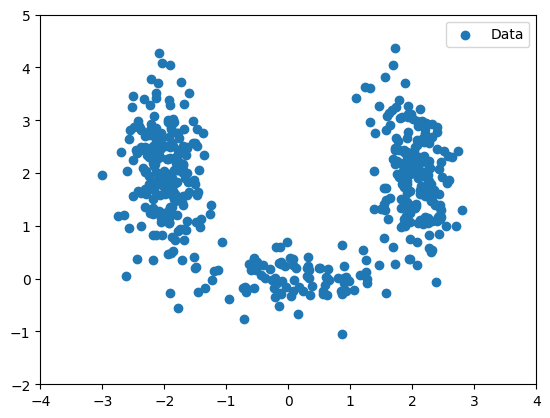

In [2]:
##### DO NOT CHANGE #####
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg
import scipy.special

data = np.load("samples_u.npy")

np.random.seed(123)

plt.scatter(data[:,0], data[:,1], label='Data')
plt.xlim(-4, 4)
plt.ylim(-2, 5)
plt.legend()
plt.show()

##### DO NOT CHANGE #####

## 1) Expectation Maximization for Gaussian Mixture Models (14P)

In this exercise, we implement the expectation maximization (EM) algorithm to fit a Gaussian mixture model (GMM) to data. 
We start with an implementation of the log-density of a single Gaussian. 
We already saw an implementation of this in the first exercise and noted there that it was not the "proper" way of doing it. 
Here, we provide a better implementation. 
Compare the two implementations.

In [3]:
##### DO NOT CHANGE #####
def gaussian_log_density(samples: np.ndarray, mean: np.ndarray, covariance: np.ndarray) -> np.ndarray:
    """
    Computes the log-density of samples under a Gaussian distribution in a stable and efficient manner.
    :param samples: samples (shape: [N, dim])
    :param mean: mean of the distribution (shape: [dim])
    :param covariance: covariance of the distribution (shape: [dim, dim])
    :return: log N(x | mean, covariance) (shape: [N])
    """
    dim = mean.shape[0]

    # Recall:
    #  log N(x | mu, Sigma) = - 0.5 * dim * log(2pi)
    #                         - 0.5 * log det Sigma
    #                         - 0.5 * (x - mu)^T Sigma^(-1) (x - mu)

    # Everything is more stable using the Cholesky decomposition!
    #  Sigma = L L^T, where L is lower triangular
    chol_covariance = np.linalg.cholesky(covariance)

    # compute constant term: -0.5 * dim * log(2pi)
    const_term = dim * np.log(2 * np.pi)  # float

    # compute log-determinant: -0.5 * log det Sigma = -0.5 * log prod diag(L)
    logdet_term = 2 * np.sum(np.log(np.diagonal(chol_covariance) + 1e-25))  # scalar

    # compute exponential term:
    #  (x - mu)^T Sigma^(-1) (x - mu) = ((x - mu) L^(-1))^T * (L^(-1) (x - mu))
    diff = samples - mean[None, :]  # shape (N, dim)
    sol = scipy.linalg.solve_triangular(chol_covariance, diff.T, lower=True).T  # (N, dim)
    exp_term = np.sum(np.square(sol), axis=-1)  # (N,)
    return -0.5 * (const_term + logdet_term + exp_term)

##### DO NOT CHANGE #####

We also provide some plotting functionality for 2D GMMs:

In [4]:
##### DO NOT CHANGE #####
COLORS = ['tab:blue', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:grey',
          'tab:olive', 'tab:cyan']

def visualize_2d_gmm(samples, weights, means, covs, title):
    """Visualize the model and the samples."""
    plt.figure(figsize=[7,7])
    plt.title(title)
    plt.scatter(samples[:, 0], samples[:, 1], label="Samples", c=COLORS[0])

    for i in range(means.shape[0]):
        (largest_eigval, smallest_eigval), eigvec = np.linalg.eigh(covs[i])
        phi = -np.arctan2(eigvec[0, 1], eigvec[0, 0])

        plt.scatter(means[i, 0:1], means[i, 1:2], marker="x", c=COLORS[i+1])

        a = 2.0 * np.sqrt(largest_eigval)
        b = 2.0 * np.sqrt(smallest_eigval)

        ellipse_x_r = a * np.cos(np.linspace(0, 2 * np.pi, num=200))
        ellipse_y_r = b * np.sin(np.linspace(0, 2 * np.pi, num=200))

        R = np.array([[np.cos(phi), np.sin(phi)], [-np.sin(phi), np.cos(phi)]])
        r_ellipse = np.array([ellipse_x_r, ellipse_y_r]).T @ R
        plt.plot(means[i, 0] + r_ellipse[:, 0], means[i, 1] + r_ellipse[:, 1],
                 label="Component {:02d}, Weight: {:0.4f}".format(i, weights[i]), c=COLORS[i+1])
    plt.legend()
    plt.xlim(-4, 4)
    plt.ylim(-2, 5)

##### DO NOT CHANGE #####

### 1.1) Log Joint Density (2P)

In the next cell, implement the log joint density $\log p(x, k) = \log \left( p(x | z = k) p(z = k) \right)$ for all components $k$ of a GMM.
Given an array of $N$ samples each of shape `dim`, return an array of shape `[N, num_components]`, where the entry at position $(i, k)$ equals $\log p(x_i, k)$.

Make sure to always stay in log space - never convert log probabilities to (non-log) regular probabilities.
Use the `gaussian_log_density` function from above.
You are allowed to use a `for` loop to iterate over the GMM components.

In [5]:
def compute_log_joint_densities(samples: np.ndarray, weights: np.ndarray, means: np.ndarray, covariances: np.ndarray) -> np.ndarray:
    """
    Computes the log joint densities of samples under a GMM, given model parameters.
    :param samples: samples (shape: [N, dim])
    :param weights: mixture weights, i.e., p(z) (shape: [num_components])
    :param means: component means, i.e., means of p(x|z) (shape: [num_components, dim])
    :param covariances: component covariances, i.e., means of p(x|z) (shape: [num_components, dim, dim])
    :return: log joint densities, i.e., log (p(x|z = k)p(z = k)) (shape: [N, num_components])
    """

    log_joint_densities = None

    # TODO: Compute the log joint densities log ( p(x_n | z = k) p(z = k) ) of the supplied GMM.
    # YOUR CODE HERE
    for i, weight in enumerate(weights):
        N = gaussian_log_density(samples, means[i], covariances[i])
        product = weight * N
        log_joint_densities[:i] = product
        

    return log_joint_densities

In [6]:
##### DO NOT CHANGE #####
# ID: test_task_1_1 - possible points: 2

np.random.seed(0)
test_samples = np.random.randn(10, 2)
test_weights = np.array([0.1, 0.3, 0.6])
test_means = np.array([[0, 0], [1, 1], [2, 2]])
test_covariances = np.array([[[1, 0], [0, 1]], [[1, 0], [0, 1]], [[1, 0], [0, 1]]])

test_joints = compute_log_joint_densities(test_samples, test_weights, test_means, test_covariances)
assert test_joints is not None
assert test_joints.shape == (10, 3), test_joints.shape
assert np.all(test_joints <= 0.0)


##### DO NOT CHANGE #####

TypeError: 'NoneType' object does not support item assignment

### 1.2) Log Likelihood (1P)

In the next cell, implement the (marginal) log-likelihood $\log p(x) = \log \sum_k p(x | z = k) p(z = k) $ of a GMM.

Again, stay in log space as much as possible.
However, there is no identity for the logarithm of a sum without taking the exponential of the inner terms.
Our only option is the log-sum-exp trick, accessible via `scipy.special.logsumexp(a, axis)`, which computes $\log \sum_i \exp(a[i])$ in a numerically stable way.
Make sure to use this function.

In [ ]:
def compute_gmm_log_likelihood(log_joint_densities: np.ndarray) -> np.ndarray:
    """
    Computes the log-likelihood of a GMM based on the log joint densities.
    :param log_joint_densities: log joint densities, i.e., log p(x | z = k) p(z = k) (shape: [N, k])
    :return: log-likelihood, i.e., log p(x_n) = log sum_k p(x_n | z = k) p(z = k) (shape: [N])
    """

    marginal_densities = None

    # TODO: Implement the log-likelihood log p(x_n) = log sum_k p(x_n | z = k) p(z = k) for GMMs.
    # YOUR CODE HERE
    raise NotImplementedError()

    return marginal_densities

In [ ]:
##### DO NOT CHANGE #####
# ID: test_task_1_2 - possible points: 1

np.random.seed(0)
test_joints = -10.0 * np.random.rand(10, 3)

test_marginals = compute_gmm_log_likelihood(test_joints)
assert test_marginals is not None
assert test_marginals.shape == (10,), test_marginals.shape


##### DO NOT CHANGE #####

### 1.3) E-Step (2P)

In the next cell, implement the E-Step of the EM algorithm for GMMs.

Use `compute_gmm_log_likelihood` and `compute_log_joint_densities` from above.
Make sure to stay in log space throughout your code.

In [ ]:
def e_step(samples: np.ndarray, weights: np.ndarray, means: np.ndarray, covariances: np.ndarray) -> np.ndarray:
    """
    E-Step of EM for fitting GMMs. Computes responsibilities, p(z|x), given samples and model parameters.
    :param samples: samples on which to compute the responsibilities (shape: [N, dim])
    :param weights: weights (i.e., p(z)) of model (shape: [num_components])
    :param means: means of components p(x|z) (shape: [num_components, dim])
    :param covariances: covariances of model components p(x|z) (shape: [num_components, dim, dim])
    :return: responsibilities p(z|x) (shape: [N x num_components])
    """

    log_responsibilities = None

    # TODO Implement the E-Step of EM for GMMs.
    # YOUR CODE HERE
    raise NotImplementedError()

    return np.exp(log_responsibilities)

In [ ]:
##### DO NOT CHANGE #####
# ID: test_task_1_3 - possible points: 2

np.random.seed(0)
test_samples = np.random.randn(10, 2)
test_weights = np.array([0.1, 0.3, 0.6])
test_means = np.array([[0, 0], [1, 1], [2, 2]])
test_covariances = np.array([[[1, 0], [0, 1]], [[1, 0], [0, 1]], [[1, 0], [0, 1]]])

test_responsibilities = e_step(test_samples, test_weights, test_means, test_covariances)
assert test_responsibilities is not None
assert test_responsibilities.shape == (10, 3), test_responsibilities.shape
assert np.allclose(test_responsibilities.sum(axis=1), 1)


##### DO NOT CHANGE #####

### 1.4) M-Step (1P + 2P + 2P)

In the next cell, implement the M-Step of the EM algorithm for GMMs.
Return the new component weights $p(z)$ and the new per-component means and covariances of $p(x | z)$.

In [ ]:
def m_step(samples: np.ndarray, responsibilities: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    M-Step of EM for fitting GMMs. Computes new parameters given samples and responsibilities p(z|x).
    :param samples: samples (shape: [N, dim])
    :param responsibilities: p(z|x) (shape: [N x num_components])
    :return: - new weights p(z) (shape: [num_components])
             - new means of components p(x|z) (shape: [num_components, dim])
             - new covariances of components p(x|z) (shape: [num_components, dim, dim]
    """

    new_weights = None
    new_means = None
    new_covs = None

    # TODO: Implement the M-Step for EM for GMMs.
    # YOUR CODE HERE
    raise NotImplementedError()

    return new_weights, new_means, new_covs

In [ ]:
##### DO NOT CHANGE #####
np.random.seed(0)
test_samples = np.random.randn(10, 2)
test_responsibilities = scipy.special.softmax(np.random.randn(10, 3), axis=1)

test_new_weights, test_new_means, test_new_covs = m_step(test_samples, test_responsibilities)

assert test_new_weights is not None
assert test_new_weights.shape == (3,), test_new_weights.shape

assert test_new_means is not None
assert test_new_means.shape == (3, 2), test_new_means.shape

assert test_new_covs is not None
assert test_new_covs.shape == (3, 2, 2), test_new_covs.shape

##### DO NOT CHANGE #####

In [ ]:
##### DO NOT CHANGE #####
# ID: test_task_1_4_weights - possible points: 1

# Tests that weights are correct


##### DO NOT CHANGE #####

In [ ]:
##### DO NOT CHANGE #####
# ID: test_task_1_4_means - possible points: 2

# Tests that means are correct


##### DO NOT CHANGE #####

In [ ]:
##### DO NOT CHANGE #####
# ID: test_task_1_4_covs - possible points: 2

# Tests that covariances are correct


##### DO NOT CHANGE #####

### 1.5) EM Algorithm

Nothing for you to do here.

The next cell defines the complete EM algorithm, alternating between E-step and M-step for a fixed number of iterations, and visualizing the intermediate results along the way.
You can use this to cross-check your implementation.

The final model should fit the data reasonably well, and reach a log-likelihood of roughly -2.4.

In [ ]:
##### DO NOT CHANGE #####
def fit_gaussian_mixture(samples: np.ndarray, num_components: int, num_iters: int = 30, vis_interval: int = 5):
    """
    Fit a Gaussian Mixture Model using the Expectation Maximization Algorithm.
    :param samples: samples to fit the GMM to (shape: [N, dim])
    :param num_components: number of components of the GMM
    :param num_iters: number of iterations
    :param vis_interval: after how many iterations to generate the next plot
    :return: - final weights p(z) (shape: [num_components])
             - final means of components p(x|z) (shape: [num_components, dim])
             - final covariances of components p(x|z) (shape: [num_components, dim, dim])
             - log_likelihoods: log-likelihood of data under model after each iteration (shape: [num_iters + 1])
    """
    # Initialize model:
    #  We initialize with means randomly picked from the data, unit covariances and uniform
    #  component weights. In general, smarter initialization techniques might be necessary, e.g., k-Means.
    initial_idx = np.random.choice(len(samples), num_components, replace=False)
    means = samples[initial_idx]
    covs = np.tile(np.eye(samples.shape[-1])[None, ...], [num_components, 1, 1])
    weights = np.ones(num_components) / num_components

    # bookkeeping
    log_likelihoods = np.zeros(num_iters + 1)

    # iterate E- and M-steps
    for i in range(num_iters):
        # plotting, bookkeeping
        if i % vis_interval == 0:
            visualize_2d_gmm(samples, weights, means, covs, title=f"Before Iteration {i:02d}")
        log_likelihoods[i] = np.mean(compute_gmm_log_likelihood(compute_log_joint_densities(samples, weights, means, covs)))

        # perform step
        responsibilities = e_step(samples, weights, means, covs)
        weights, means, covs = m_step(samples, responsibilities)

    # final plotting, bookkeeping
    visualize_2d_gmm(samples, weights, means, covs, title="Final model")
    log_likelihoods[-1] = np.mean(compute_gmm_log_likelihood(compute_log_joint_densities(samples, weights, means, covs)))

    return weights, means, covs, log_likelihoods

##### DO NOT CHANGE #####

Finally we load some data and run the algorithm. Feel free to modify the next cell to play around with the parameters.

In [ ]:
# hyperparameters
seed = 42
num_components = 3
num_iters = 30
vis_interval = 5

In [ ]:
##### DO NOT CHANGE #####
# ID: dummy_test_pls_ignore - possible points: 0

# IGNORE THIS CELL, YOU CAN'T GET ANY POINTS
# This cell disables training during notebook testing.
# There is no associated task, and you can't get any points here.

TRAIN = True


##### DO NOT CHANGE #####

In [ ]:
##### DO NOT CHANGE #####
if TRAIN:
    # dataset
    data = np.load("samples_u.npy")

    # running and ploting
    np.random.seed(seed)
    final_weights, final_means, final_covariances, log_likelihoods = \
        fit_gaussian_mixture(data, num_components, num_iters, vis_interval)
    visualize_2d_gmm(data, final_weights, final_means, final_covariances, title="Final Model")

    plt.figure()
    plt.title("Log-likelihoods over iterations")
    plt.plot(log_likelihoods)
    plt.xlabel("iteration")
    plt.ylabel("log-likelihood")
    plt.show()

##### DO NOT CHANGE #####

### 1.6) Sampling from the GMM (3P)

So far we only fitted the GMM, but never used it to generate new data.
In the next cell, implement ancestral sampling for GMMs.
First draw a component index $k \sim p(z)$ for each sample, then draw the sample itself from the corresponding component $p(x | z = k)$.

Draw the component indices with `np.random.choice`.
To sample from a component, transform standard-normal noise with the Cholesky decomposition of its covariance, i.e., $x = \mu_k + L_k \epsilon$ with $\Sigma_k = L_k L_k^T$ and $\epsilon \sim \mathcal{N}(0, I)$.

**Important:** Write the component indices to `indices` and the raw standard-normal noise to `noise`. We need both for testing.

In [ ]:
def sample_gmm(num_samples: int, weights: np.ndarray, means: np.ndarray, covariances: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Samples from a GMM by first drawing a component index from p(z) and then drawing a sample from that component p(x|z).
    :param num_samples: number of samples to draw
    :param weights: mixture weights, i.e., p(z) (shape: [num_components])
    :param means: component means, i.e., means of p(x|z) (shape: [num_components, dim])
    :param covariances: component covariances of p(x|z) (shape: [num_components, dim, dim])
    :return: - component indices drawn from p(z) (shape: [num_samples])
             - standard-normal noise used to generate the samples (shape: [num_samples, dim])
             - samples (shape: [num_samples, dim])
    """

    indices = None
    noise = None
    samples = None

    # TODO: Implement ancestral sampling for GMMs.
    # TODO: Use np.random.choice to sample a component index, and np.random.randn together with np.linalg.cholesky to sample from the components
    # YOUR CODE HERE
    raise NotImplementedError()

    return indices, noise, samples

In [ ]:
##### DO NOT CHANGE #####
# ID: test_task_1_6 - possible points: 3

np.random.seed(0)
test_weights = np.array([0.1, 0.3, 0.6])
test_means = np.array([[0, 0], [1, 1], [2, 2]])
test_covariances = np.array([[[1, 0], [0, 1]], [[1, 0], [0, 1]], [[1, 0], [0, 1]]])

test_indices, test_noise, test_samples = sample_gmm(10, test_weights, test_means, test_covariances)

assert test_indices is not None
assert test_indices.shape == (10,), test_indices.shape
assert np.all((test_indices >= 0) & (test_indices < 3))

assert test_noise is not None
assert test_noise.shape == (10, 2), test_noise.shape

assert test_samples is not None
assert test_samples.shape == (10, 2), test_samples.shape


##### DO NOT CHANGE #####

The next cell draws samples from your fitted GMM and plots them.
They should roughly follow the U-shape of the data.

In [ ]:
##### DO NOT CHANGE #####
if TRAIN:
    np.random.seed(seed)
    _, _, gmm_samples = sample_gmm(750, final_weights, final_means, final_covariances)

    plt.figure(figsize=[7, 7])
    plt.title("Samples from the fitted GMM")
    plt.scatter(gmm_samples[:, 0], gmm_samples[:, 1], label="Samples", c=COLORS[0], s=10)
    plt.xlim(-4, 4)
    plt.ylim(-2, 5)
    plt.show()

##### DO NOT CHANGE #####

### 1.7) Properties of EM (1P)

Based on the log-likelihood curve above and your knowledge from the lecture, which of the following statements about EM is correct?

- a) The log-likelihood never decreases, and EM converges to the global optimum.
- b) The log-likelihood never decreases, but EM can converge to a local optimum.
- c) The log-likelihood can decrease in single iterations, but EM converges to the global optimum.
- d) The log-likelihood can decrease in single iterations, and EM can converge to a local optimum.

In the next cell, write your answer as a Python string containing one lowercase letter in `answer_1_7`.

In [ ]:
answer_1_7 = None
# YOUR CODE HERE
raise NotImplementedError()

In [ ]:
##### DO NOT CHANGE #####
# ID: test_task_1_7 - possible points: 1

assert answer_1_7 in ("a", "b", "c", "d")


##### DO NOT CHANGE #####

## 2) Variational Autoencoders (9P)

In this exercise, we implement a Variational Autoencoder (VAE). We will test the model on the same (U-shaped) data that we used to train our GMM.

This task requires PyTorch. However, you do not need a GPU, as the model is small enough to train on a CPU.

First, we import some libraries, standardize the data, and create train and test splits.

In [ ]:
##### DO NOT CHANGE #####
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

data = np.load("samples_u.npy")

scaler = StandardScaler()
X = scaler.fit_transform(data)  # Standardize data

# Split the dataset
X_train, X_val = train_test_split(X, test_size=0.2, random_state=42)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)

##### DO NOT CHANGE #####

Next, we define the encoder and decoder models as simple MLPs with ReLU activations.
Note how the encoder has separate linear layers for the mean (`fc_mu`) and log-variance (`fc_logvar`) of its predictive distribution.

In [ ]:
##### DO NOT CHANGE #####
class VAE(nn.Module):
    """A small VAE for 2D data with a Gaussian encoder and decoder."""

    def __init__(self, input_dim: int, hidden_dim: int, latent_dim: int):
        super().__init__()
        self.latent_dim = latent_dim

        # Encoder q(z | x): maps x to the mean and log-variance of the latent.
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder p(x | z): maps a latent to the mean of a Gaussian in data space.
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
        )

    def encode(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        return self.decoder(z)

##### DO NOT CHANGE #####

### 2.1) Reparameterization Trick (1P)

Implement the reparameterization trick in `reparameterize`.
Given means $\mu \in \mathbb{R}^{N \times D}$ and log-variances $\log (\sigma^2) \in \mathbb{R}^{N \times D}$, generate random numbers that follow $\mathcal{N}(\mu, \sigma^2)$.

**Important:** Write the raw, un-transformed standard-normal random numbers that PyTorch gives you to `eps`. We need this for testing.

**Hint:** Check out `torch.randn_like`, it makes the code a bit shorter (but is not necessary).

In [ ]:
def reparameterize(mean: torch.Tensor, log_var: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Sample from a multivariate Gaussian N(mean, var) with diagonal covariance using the reparameterization trick to stay differentiable w.r.t. to both distribution parameters.
    :param mean: Mean of the Gaussian (shape [N, D])
    :param log_var: Logarithm of the Gaussian's variance (shape [N, D])
    :return Random standard-normally distributed numbers used for sample generation and reparameterized samples
    """
    
    eps = None
    samples = None

    # YOUR CODE HERE
    raise NotImplementedError()

    return eps, samples

In [ ]:
##### DO NOT CHANGE #####
# ID: test_task_2_1 - possible points: 1

test_mean = torch.tensor([[0.0, 0.0], [1.0, 1.0]])
test_log_var = torch.tensor([[0.0, 0.0], [0.0, 0.0]])
test_eps, test_samples = reparameterize(test_mean, test_log_var)

assert test_eps is not None
assert test_eps.shape == (2, 2), test_eps.shape

assert test_samples is not None
assert test_samples.shape == (2, 2), test_samples.shape


##### DO NOT CHANGE #####

### 2.2) VAE Loss (2P + 2P)

Implement the VAE loss function for a batch of samples
$$ 
\begin{align}
\mathcal{L} &= -\mathbb{E}_{z \sim q(z \;|\; x)}[\log p(x \;|\; z)] + \text{KL}[q(z \;|\; x) \;||\; p(z)] \\
&\approx -\log \mathcal{N}(x \;|\; \hat{x}, \sigma^2_x) + \text{KL}[\mathcal{N}(\mu_z, \sigma^2_z) \;||\; \mathcal{N}(0, I)]
\end{align}
$$
where $x$ is a data sample, $\hat{x}$ is the reconstructed data sample (using the reparameterization trick to get an encoder sample), and $\mu_z$, $\sigma_z^2$ parameterize the encoder output distribution for $x$, and $\sigma^2_x$ is the (fixed) output variance of the decoder.

The closed-form solution for the KL divergence between two univariate Gaussians $\mathcal{N}(\mu_1, \sigma^2_1)$ and $\mathcal{N}(\mu_2, \sigma^2_2)$ is given by
$$
\begin{align}
\text{KL}[\mathcal{N}(\mu_1, \sigma^2_1) \;||\; \mathcal{N}(\mu_2, \sigma^2_2)] = \frac{1}{2} \left( \log \sigma^2_2 - \log \sigma^2_1 + \frac{\sigma_1^2 + (\mu_1 - \mu_2)^2}{\sigma_2^2} - 1 \right).
\end{align}
$$
The KL divergence between two $D$-dimensional multivariate Gaussians with means $\boldsymbol{\mu}_1, \boldsymbol{\mu}_2 \in \mathbf{R}^D$ and diagonal covariances $\boldsymbol{\sigma}^2_1, \boldsymbol{\sigma}^2_2 \in \mathbf{R}^D$ is the sum of the dimension-wise KL divergences:
$$
\begin{align}
\text{KL}[\mathcal{N}(\boldsymbol{\mu}_1, \boldsymbol{\sigma}^2_1) \;||\; \mathcal{N}(\boldsymbol{\mu}_2, \boldsymbol{\sigma}^2_2)] = \sum_{d=1}^D \text{KL}[\mathcal{N}(\mu_{1, d}, \sigma^2_{1, d}) \;||\; \mathcal{N}(\mu_{2, d}, \sigma^2_{2, d})]
\end{align}
$$

Compute the reconstruction error and prior KL term separately.
Do not sum across samples $N$ in the code that you write, only across sample dimensions $D$.
The function epilogue does the averaging across samples for you.

In [ ]:

def vae_loss(x: torch.Tensor, x_recon: torch.Tensor, z_mean: torch.Tensor, z_log_var: torch.Tensor, sigma: float) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Computes the VAE loss for a batch of samples x, where q(z | x) = N(z_mean, z_var), and the decoder's predictive distribution p(x | z) is N(x_recon, sigma^2) for a z ~ q(z | x).
    :param x: Batch of samples (shape [N, D])
    :param x_recon: Batch of reconstructed sample means of p(x | z) (shape [N, D])
    :param z_mean: Mean of the encoder's latent variable distribution q(z | x) (shape [N, L])
    :param z_log_var: Logarithm of the variance of the encoder's latent variable distribution q(z | x) (shape [N, L])
    :param sigma: Scalar output standard deviation of the decoder
    :return Scalar mean reconstruction error and scalar mean prior KL divergence
    """

    recon_loss = None
    kl_loss = None

    # TODO implement the sample-wise VAE loss
    # TODO Compute the reconstruction error and prior KL separately and write them to recon_loss and kl_loss, respectively.
    # YOUR CODE HERE
    raise NotImplementedError()

    assert recon_loss.shape == (x.shape[0],)
    assert kl_loss.shape == (x.shape[0],)

    return torch.mean(recon_loss), torch.mean(kl_loss)


In [ ]:
##### DO NOT CHANGE #####
torch.manual_seed(0)
test_x = torch.randn(10, 2)
test_x_recon = torch.randn(10, 2)
test_z_mean = torch.randn(10, 3)
test_z_log_var = torch.randn(10, 3)

test_recon, test_kl = vae_loss(test_x, test_x_recon, test_z_mean, test_z_log_var, 0.5)

assert test_recon is not None
assert test_recon.shape == (), test_recon.shape

assert test_kl is not None
assert test_kl.shape == (), test_kl.shape

##### DO NOT CHANGE #####

In [ ]:
##### DO NOT CHANGE #####
# ID: test_task_2_2_recon - possible points: 2

# Tests that the reconstruction loss is correct


##### DO NOT CHANGE #####

In [ ]:
##### DO NOT CHANGE #####
# ID: test_task_2_2_kl - possible points: 2

# Tests that the prior KL is correct


##### DO NOT CHANGE #####

### 2.3) VAE Loss Details (1P)
In the equation for the VAE loss in the previous task, the second line is not an equality, but an approximation of the first line.
What is the reason?

- a) The encoder does not match the decoder's posterior exactly.
- b) The variational gap is missing.
- c) The reconstruction error is approximated with a Monte-Carlo sample.
- d) The prior KL is approximated with a Monte-Carlo sample.

In the next cell, write your answer as a Python string containing one lowercase letter in `answer_2_3`.

In [ ]:
answer_2_3 = None
# YOUR CODE HERE
raise NotImplementedError()

In [ ]:
##### DO NOT CHANGE #####
# ID: test_task_2_3 - possible points: 1

assert answer_2_3 in ("a", "b", "c", "d")


##### DO NOT CHANGE #####

### 2.4) Training

Finally, we can kick off training.
Nothing for you to do here, though feel free to play with the hyperparameters.

Training should take at most a few minutes, even on a Laptop CPU.

In [ ]:
# Feel free to edit this cell and change hyperparameters

# Model hyperparameters
input_dim = 2
hidden_dim = 256

latent_dim = 2   # latent dimensionality

sigma = 0.2      # decoder observation noise; sets the reconstruction/KL balance.
                 # 0.2 favors reconstruction, 0.4 favors a nice, Gaussian latent space

# Training hyperparameters
epochs = 500
learning_rate = 1e-3
batch_size = 128

In [ ]:
##### DO NOT CHANGE #####
# ID: dummy_test_pls_ignore_2 - possible points: 0

# IGNORE THIS CELL, YOU CAN'T GET ANY POINTS
# This cell disables training during notebook testing.
# There is no associated task, and you can't get any points here.

TRAIN = True


##### DO NOT CHANGE #####

In [ ]:
##### DO NOT CHANGE #####
torch.manual_seed(0)

if TRAIN:
    model = VAE(input_dim, hidden_dim, latent_dim)

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_dataset = TensorDataset(X_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    recon_history, kl_history, loss_history = [], [], []
    for epoch in range(epochs):
        model.train()
        epoch_recon, epoch_kl = 0.0, 0.0
        for batch in train_loader:
            x = batch[0]

            # encode sample
            z_mean, z_logvar = model.encode(x)

            # sample z via reparameterization
            _, z = reparameterize(z_mean, z_logvar)

            # reconstruct sample
            x_recon = model.decode(z)

            recon, kl = vae_loss(x, x_recon, z_mean, z_logvar, sigma)
            loss = recon + kl

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_recon += recon.item()
            epoch_kl += kl.item()

        epoch_recon /= len(train_loader)
        epoch_kl /= len(train_loader)

        recon_history.append(epoch_recon)
        kl_history.append(epoch_kl)
        loss_history.append(epoch_kl + epoch_recon)

        print(f"Epoch {epoch + 1}/{epochs}, Recon: {recon_history[-1]:.4f}, KL: {kl_history[-1]:.4f}")

    _, (ax0, ax1, ax2) = plt.subplots(ncols=3, figsize=(15, 5))

    ax0.plot(loss_history, label="Loss")
    ax0.legend()
    ax1.plot(recon_history, label="Reconstruction Error")
    ax1.legend()
    ax2.plot(kl_history, label="Prior KL")
    ax2.legend()
    plt.show()

##### DO NOT CHANGE #####

### 2.5) VAE Sampling (2P)

We can generate a sample $x$ from the VAE by first generating a latent $z$ from the prior $p(z)$, and then sampling from the decoder's output:
$$
\begin{align}
z &\sim p(z) \\
x &\sim p_\theta(x \;|\; z)
\end{align}
$$
where $p_\theta(x \;|\; z)= \mathcal{N}\left(x \;|\; \mu_\theta(z), \sigma^2_x\right)$.

One common trick to improve sample quality is to not actually sample from decoder's predictive distribution $p(x \;|\; z)$, but to directly use its mean $\mu_\theta(z)$ as the sample.

Implement this sampling procedure with the deterministic decoder in `sample_vae`.

**Important:** Write the raw, untransformed standard normal sample that you got from `torch.randn` to `z`. We need this for testing.

In [ ]:
def sample_vae(num_samples: int, latent_dim: int, model: VAE) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Generates samples from a trained VAE by drawing latents from the prior p(z) = N(0, I) and decoding them to the mean of p(x | z).
    :param num_samples: Number of samples to generate
    :param latent_dim: Dimensionality of the latent space
    :param model: Trained VAE whose decoder maps a latent to the mean of p(x | z)
    :return Standard-normally distributed latents drawn from the prior (shape [num_samples, latent_dim]) and the decoded samples (shape [num_samples, D])
    """

    z = None
    samples = None

    # TODO: Sample latents from the prior and decode them into samples.
    # YOUR CODE HERE
    raise NotImplementedError()

    return z, samples

In [ ]:
##### DO NOT CHANGE #####
# ID: test_task_2_5 - possible points: 2

torch.manual_seed(0)
test_model = VAE(input_dim=2, hidden_dim=16, latent_dim=3)

test_z, test_samples = sample_vae(5, 3, test_model)

assert test_z is not None
assert test_z.shape == (5, 3), test_z.shape

assert test_samples is not None
assert test_samples.shape == (5, 2), test_samples.shape


##### DO NOT CHANGE #####

The next cell generates a few hundred samples from your VAE and plots them.
If you did everything right, they should look roughly U-shaped, with, most likely, some stray samples in the center of the U.

In [ ]:
##### DO NOT CHANGE #####
torch.manual_seed(0)

if TRAIN:
    num_samples = 750

    with torch.no_grad():
        model.eval()
        _, samples = sample_vae(num_samples, latent_dim, model)
        samples = samples.numpy()

    final_samples = scaler.inverse_transform(samples)

    plt.figure(figsize=[7, 7])
    plt.title("Samples")
    plt.scatter(final_samples[:, 0], final_samples[:, 1], label="Samples", c='tab:blue', s=10)
    plt.xlim(-4, 4)
    plt.ylim(-2, 5)
    plt.show()

##### DO NOT CHANGE #####

### 2.6) Decoder Variance (1P)

The hyperparameter cell above states that a small $\sigma_x$ favors reconstruction quality, while a larger one favors a latent space that matches the prior.
Why is that the case?

- a) A larger $\sigma_x$ scales down the reconstruction error, so the prior KL dominates the loss.
- b) A larger $\sigma_x$ gives the decoder more capacity, so it needs less regularization.
- c) A larger $\sigma_x$ widens the prior $p(z)$, which the encoder can match more easily.
- d) A larger $\sigma_x$ makes the encoder deterministic, so the reparameterization trick has no effect.

In the next cell, write your answer as a Python string containing one lowercase letter in `answer_2_6`.

In [ ]:
answer_2_6 = None
# YOUR CODE HERE
raise NotImplementedError()

In [ ]:
##### DO NOT CHANGE #####
# ID: test_task_2_6 - possible points: 1

assert answer_2_6 in ("a", "b", "c", "d")


##### DO NOT CHANGE #####